(np)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`NumPy <single: NumPy>`

```{index} single: Python; NumPy
```

```{epigraph}
"Let's be clear: the work of science has nothing whatever to do with consensus.  Consensus is the business of politics. Science, on the contrary, requires only one investigator who happens to be right, which means that he or she has results that are verifiable by reference to the real world. In science consensus is irrelevant. What is relevant is reproducible results." -- Michael Crichton
```

Anaconda-യിൽ ഉള്ളതിന് പുറമേ, ഈ lecture-ന് താഴെ പറയുന്ന libraries ആവശ്യമായിവരുന്നു:

In [1]:
!pip install quantecon

## Overview

[NumPy](https://en.wikipedia.org/wiki/NumPy) എന്നത്, numerical programming-നുള്ള ഒരു മികച്ച library ആണ്.

* Academia, finance, industry എന്നിവയിൽ വ്യാപകമായി ഉപയോഗിക്കപ്പെടുന്നു.
* Mature-ഉം, fast-ഉം, stable-ഉം ആണ്, തുടർച്ചയായി development-ലും ആണ്.

മുൻ lectures-ൽ NumPy ഉൾപ്പെടുന്ന കുറച്ച് code നമ്മൾ already കണ്ടിട്ടുണ്ട്.

ഈ lecture-ൽ നമ്മൾ ചെയ്യാൻ പോകുന്ന കാര്യങ്ങൾ:

1. NumPy arrays, ഒപ്പം
1. NumPy നൽകുന്ന അടിസ്ഥാന array processing operations.

(ഒരു alternative reference-ന്, [the official NumPy documentation](https://numpy.org/doc/stable/reference/) നോക്കുക.)

താഴെ പറയുന്ന imports നമുക്ക് ഉപയോഗിക്കാം.

In [2]:
import numpy as np
import random
import quantecon as qe
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm

(numpy_array)=
## NumPy Arrays

```{index} single: NumPy; Arrays
```

NumPy പരിഹരിക്കുന്ന അടിസ്ഥാന പ്രശ്നം, വേഗതയേറിയ array processing ആണ്.

NumPy define ചെയ്യുന്ന ഏറ്റവും പ്രധാനപ്പെട്ട structure, ഒരു array data type ആണ്, ഔപചാരികമായി ഇതിനെ [numpy.ndarray](https://numpy.org/doc/stable/reference/arrays.ndarray.html) എന്ന് വിളിക്കുന്നു.

Scientific Python ecosystem-ന്റെ വളരെ വലിയൊരു ഭാഗം NumPy arrays ആണ് പ്രവർത്തിപ്പിക്കുന്നത്.

### Basics

Zeros മാത്രം അടങ്ങിയ ഒരു NumPy array create ചെയ്യാൻ നമ്മൾ [np.zeros](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html#numpy.zeros) ഉപയോഗിക്കുന്നു.

In [3]:
a = np.zeros(3)
a

array([0., 0., 0.])

In [4]:
type(a)

numpy.ndarray

NumPy arrays, native Python lists-നെ കുറച്ചൊക്കെ പോലെയാണ്, പക്ഷേ വ്യത്യാസം എന്തെന്നാൽ:

* Data *homogeneous ആയിരിക്കണം* (എല്ലാ elements-ഉം ഒരേ type-ലുള്ളതായിരിക്കണം).
* ഈ types, NumPy നൽകുന്ന [data types](https://numpy.org/doc/stable/reference/arrays.dtypes.html) (`dtypes`) ഇൽ ഒന്നായിരിക്കണം.

ഈ dtypes-ൽ ഏറ്റവും പ്രധാനപ്പെട്ടവ:

* float64: 64 bit floating-point number
* int64: 64 bit integer
* bool: 8 bit True or False

Complex numbers, unsigned integers, തുടങ്ങിയവ represent ചെയ്യാൻ ഉള്ള dtypes-ഉം ഉണ്ട്.

ആധുനിക machines-ൽ, arrays-ന്റെ default dtype `float64` ആണ്.

In [5]:
a = np.zeros(3)
type(a[0])

numpy.float64

Integers ഉപയോഗിക്കണമെങ്കിൽ താഴെ കാണിച്ചിരിക്കുന്ന പോലെ specify ചെയ്യാം:

In [6]:
a = np.zeros(3, dtype=int)
type(a[0])

numpy.int64

(numpy_shape_dim)=
### Shape and Dimension

```{index} single: NumPy; Arrays (Shape and Dimension)
```

താഴെ കൊടുത്തിരിക്കുന്ന assignment നോക്കാം:

In [7]:
z = np.zeros(10)

ഇവിടെ `z` എന്നത് ഒരു **flat** array ആണ് --- row vector-ഉം അല്ല column vector-ഉം അല്ല.

In [8]:
z.shape

(10,)

ഇവിടെ shape tuple-ന് ഒരു element മാത്രമേയുള്ളൂ, അതായത് array-യുടെ length (ഒരു element മാത്രമുള്ള tuples ഒരു comma-യിൽ അവസാനിക്കും).

ഇതിന് ഒരു additional dimension നൽകാൻ, `shape` attribute നമുക്ക് മാറ്റാം:

In [9]:
z.shape = (10, 1)   # Convert flat array to column vector (two-dimensional)
z

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [10]:
z = np.zeros(4)     # Flat array
z.shape = (2, 2)    # Two-dimensional array
z

array([[0., 0.],
       [0., 0.]])

അവസാനത്തെ case-ൽ, 2x2 array ഉണ്ടാക്കാൻ, `zeros()` function-ന് ഒരു tuple pass ചെയ്യാം, `z = np.zeros((2, 2))` എന്ന പോലെ.



(creating_arrays)=
### Creating Arrays

```{index} single: NumPy; Arrays (Creating)
```

നമ്മൾ കണ്ടത് പോലെ, `np.zeros` function zeros-ന്റെ ഒരു array create ചെയ്യുന്നു.

`np.ones` എന്താണ് create ചെയ്യുന്നതെന്ന് നിങ്ങൾക്ക് ഊഹിക്കാൻ കഴിയും.

ഇതുമായി ബന്ധപ്പെട്ടതാണ് `np.empty`, ഇത് memory-യിൽ arrays create ചെയ്യുന്നു, പിന്നീട് data-കൊണ്ട് നിറയ്ക്കാവുന്നത്:

In [11]:
z = np.empty(3)
z

array([0., 0., 0.])

ഇവിടെ കാണുന്ന numbers garbage values ആണ്.

(Python 3 contiguous 64 bit memory pieces allocate ചെയ്യുന്നു, ആ memory slots-ലെ നിലവിലുള്ള contents `float64` values ആയി interpret ചെയ്യപ്പെടുന്നു)

Evenly spaced numbers-ന്റെ ഒരു grid set up ചെയ്യാൻ `np.linspace` ഉപയോഗിക്കുക:

In [12]:
z = np.linspace(2, 4, 5)  # From 2 to 4, with 5 elements

ഒരു identity matrix create ചെയ്യാൻ `np.identity` അല്ലെങ്കിൽ `np.eye` ഉപയോഗിക്കുക:

In [13]:
z = np.identity(2)
z

array([[1., 0.],
       [0., 1.]])

കൂടാതെ, `np.array` ഉപയോഗിച്ച് Python lists, tuples, തുടങ്ങിയവയിൽ നിന്നും NumPy arrays create ചെയ്യാം:

In [14]:
z = np.array([10, 20])                 # ndarray from Python list
z

array([10, 20])

In [15]:
type(z)

numpy.ndarray

In [16]:
z = np.array((10, 20), dtype=float)    # Here 'float' is equivalent to 'np.float64'
z

array([10., 20.])

In [17]:
z = np.array([[1, 2], [3, 4]])         # 2D array from a list of lists
z

array([[1, 2],
       [3, 4]])

`np.asarray` എന്നതും കാണുക, ഇത് similar ആയ ഒരു function ആണ്, പക്ഷേ NumPy array-യിൽ already ഉള്ള data-യുടെ distinct copy ഉണ്ടാക്കുന്നില്ല.

Numeric data അടങ്ങിയ ഒരു text file-ൽ നിന്നും array data read ചെയ്യാൻ `np.loadtxt` ഉപയോഗിക്കുക --- വിശദാംശങ്ങൾക്ക് [the documentation](https://numpy.org/doc/stable/reference/routines.io.html) കാണുക.



### Array Indexing

```{index} single: NumPy; Arrays (Indexing)
```

ഒരു flat array-ന്, indexing Python sequences-ന്റേത് പോലെ തന്നെയാണ്:

In [18]:
z = np.linspace(1, 2, 5)
z

array([1.  , 1.25, 1.5 , 1.75, 2.  ])

In [19]:
z[0]

np.float64(1.0)

In [20]:
z[0:2]  # Two elements, starting at element 0

array([1.  , 1.25])

In [21]:
z[-1]

np.float64(2.0)

2D arrays-ന് index syntax താഴെ കാണിച്ചിരിക്കുന്ന പോലെയാണ്:

In [22]:
z = np.array([[1, 2], [3, 4]])
z

array([[1, 2],
       [3, 4]])

In [23]:
z[0, 0]

np.int64(1)

In [24]:
z[0, 1]

np.int64(2)

ഇങ്ങനെ തുടരും.

Columns-ഉം, rows-ഉം താഴെ കാണിച്ചിരിക്കുന്ന പോലെ extract ചെയ്യാം:

In [25]:
z[0, :]

array([1, 2])

In [26]:
z[:, 1]

array([2, 4])

Integers-ന്റെ NumPy arrays-ഉം elements extract ചെയ്യാൻ ഉപയോഗിക്കാം:

In [27]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [28]:
indices = np.array((0, 2, 3))
z[indices]

array([2. , 3. , 3.5])

അവസാനമായി, `dtype bool` ഉള്ള ഒരു array-യും elements extract ചെയ്യാൻ ഉപയോഗിക്കാം:

In [29]:
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [30]:
d = np.array([0, 1, 1, 0, 0], dtype=bool)
d

array([False,  True,  True, False, False])

In [31]:
z[d]

array([2.5, 3. ])

ഇത് എന്തുകൊണ്ട് useful ആണെന്ന് താഴെ നമുക്ക് കാണാം.

ഒരു ചെറിയ കാര്യം കൂടി: slice notation ഉപയോഗിച്ച് ഒരു array-യിലെ എല്ലാ elements-ഉം ഒരു number-ന് തുല്യമായി set ചെയ്യാം:

In [32]:
z = np.empty(3)
z

array([2. , 3. , 3.5])

In [33]:
z[:] = 42
z

array([42., 42., 42.])

### Array Methods

```{index} single: NumPy; Arrays (Methods)
```

Arrays-ന് useful ആയ methods ഉണ്ട്, ഇവയെല്ലാം carefully optimize ചെയ്തിരിക്കുന്നു:

In [34]:
a = np.array((4, 3, 2, 1))
a

array([4, 3, 2, 1])

In [35]:
a.sort()              # Sorts a in place
a

array([1, 2, 3, 4])

In [36]:
a.sum()               # Sum

np.int64(10)

In [37]:
a.mean()              # Mean

np.float64(2.5)

In [38]:
a.max()               # Max

np.int64(4)

In [39]:
a.argmax()            # Returns the index of the maximal element

np.int64(3)

In [40]:
a.cumsum()            # Cumulative sum of the elements of a

array([ 1,  3,  6, 10])

In [41]:
a.cumprod()           # Cumulative product of the elements of a

array([ 1,  2,  6, 24])

In [42]:
a.var()               # Variance

np.float64(1.25)

In [43]:
a.std()               # Standard deviation

np.float64(1.118033988749895)

In [44]:
a.shape = (2, 2)
a.T                   # Equivalent to a.transpose()

array([[1, 3],
       [2, 4]])

അറിഞ്ഞിരിക്കേണ്ട മറ്റൊരു method ആണ് `searchsorted()`.

`z` എന്നത് ഒരു nondecreasing array ആണെങ്കിൽ, `z.searchsorted(a)` എന്നത് `z`-യിലെ `>= a` ആയ ആദ്യത്തെ element-ന്റെ index return ചെയ്യുന്നു:

In [45]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [46]:
z.searchsorted(2.2)

np.int64(1)

## Arithmetic Operations

```{index} single: NumPy; Arithmetic Operations
```

`+`, `-`, `*`, `/`, `**` എന്നീ operators എല്ലാം arrays-ൽ *elementwise* ആയി act ചെയ്യുന്നു:

In [47]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
a + b

array([ 6,  8, 10, 12])

In [48]:
a * b

array([ 5, 12, 21, 32])

താഴെ കാണിച്ചിരിക്കുന്ന പോലെ ഓരോ element-ഇനും ഒരു scalar നമുക്ക് add ചെയ്യാം:

In [49]:
a + 10

array([11, 12, 13, 14])

Scalar multiplication similar ആണ്:

In [50]:
a * 10

array([10, 20, 30, 40])

Two-dimensional arrays-ഉം അതേ general rules തന്നെ follow ചെയ്യുന്നു:

In [51]:
A = np.ones((2, 2))
B = np.ones((2, 2))
A + B

array([[2., 2.],
       [2., 2.]])

In [52]:
A + 10

array([[11., 11.],
       [11., 11.]])

In [53]:
A * B

array([[1., 1.],
       [1., 1.]])

(numpy_matrix_multiplication)=
In particular, `A * B` എന്നത് matrix product *അല്ല*, ഇത് ഒരു element-wise product ആണ്.


## Matrix Multiplication

```{index} single: NumPy; Matrix Multiplication
```

```{index} single: NumPy; Matrix Multiplication
```

Matrix multiplication-ന് നമ്മൾ `@` symbol ഉപയോഗിക്കുന്നു, താഴെ കാണിച്ചിരിക്കുന്ന പോലെ:

In [54]:
A = np.ones((2, 2))
B = np.ones((2, 2))
A @ B

array([[2., 2.],
       [2., 2.]])

Syntax flat arrays-ലും work ചെയ്യുന്നു --- നിങ്ങൾക്ക് എന്താണ് വേണ്ടതെന്ന് NumPy ഒരു educated guess നടത്തുന്നു:

In [55]:
A @ (0, 1)

array([1., 1.])

നമ്മൾ post-multiplying ചെയ്യുന്നതിനാൽ, tuple ഒരു column vector ആയി treat ചെയ്യപ്പെടുന്നു.



(broadcasting)=
## Broadcasting

```{index} single: NumPy; Broadcasting
```

(ഈ section, [Jake VanderPlas](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html) നൽകിയ broadcasting-നെക്കുറിച്ചുള്ള ഒരു മികച്ച discussion extend ചെയ്യുന്നു.)

```{note}
Broadcasting എന്നത് NumPy-യുടെ വളരെ പ്രധാനപ്പെട്ട ഒരു aspect ആണ്. അതേസമയം, advanced broadcasting താരതമ്യേന complex ആണ്, താഴെ പറയുന്ന ചില details ആദ്യമായി വായിക്കുമ്പോൾ skim ചെയ്ത് പോകാം.
```

Element-wise operations-ൽ, arrays-ന് ഒരേ shape ഉണ്ടാകണമെന്നില്ല.

ഇത് സംഭവിക്കുമ്പോൾ, കഴിയുന്നിടത്തെല്ലാം NumPy automatically arrays-നെ ഒരേ shape-ലേക്ക് expand ചെയ്യും.

NumPy-യിലെ ഈ useful ആയ (എന്നാൽ ചിലപ്പോൾ confusing ആയ) feature-നെ **broadcasting** എന്ന് വിളിക്കുന്നു.

Broadcasting-ന്റെ value എന്തെന്നാൽ:

* `for` loops ഒഴിവാക്കാം, ഇത് numerical code വേഗത്തിൽ run ചെയ്യാൻ സഹായിക്കുന്നു, ഒപ്പം
* arrays-ന്റെ ഈ dimensions memory-യിൽ actually create ചെയ്യാതെ തന്നെ arrays-ൽ operations implement ചെയ്യാൻ broadcasting നമ്മെ അനുവദിക്കുന്നു, arrays വലുതാകുമ്പോൾ ഇത് പ്രധാനമാകാം.

For example, `a` എന്നത് ഒരു $3 \times 3$ array ആണെന്ന് കരുതുക (`a -> (3, 3)`), അതേസമയം `b` എന്നത് മൂന്ന് elements ഉള്ള ഒരു flat array ആണ് (`b -> (3,)`).

ഇവയെ ഒരുമിച്ച് add ചെയ്യുമ്പോൾ, NumPy automatically `b -> (3,)` എന്നതിനെ `b -> (3, 3)` ആയി expand ചെയ്യും.

Element-wise addition-ന്റെ ഫലം ഒരു $3 \times 3$ array ആയിരിക്കും:

In [56]:
a = np.array(
        [[1, 2, 3], 
         [4, 5, 6], 
         [7, 8, 9]])
b = np.array([3, 6, 9])

a + b

array([[ 4,  8, 12],
       [ 7, 11, 15],
       [10, 14, 18]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation താഴെ കാണാം:

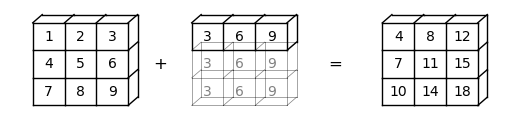

In [57]:
# Adapted and modified based on the code in the book written by Jake VanderPlas (see https://jakevdp.github.io/PythonDataScienceHandbook/06.00-figure-code.html#Broadcasting)
# Originally from astroML: see https://www.astroml.org/book_figures/appendix/fig_broadcast_visual.html


def draw_cube(ax, xy, size, depth=0.4,
              edges=None, label=None, label_kwargs=None, **kwargs):
    """draw and label a cube.  edges is a list of numbers between
    1 and 12, specifying which of the 12 cube edges to draw"""
    if edges is None:
        edges = range(1, 13)

    x, y = xy

    if 1 in edges:
        ax.plot([x, x + size],
                [y + size, y + size], **kwargs)
    if 2 in edges:
        ax.plot([x + size, x + size],
                [y, y + size], **kwargs)
    if 3 in edges:
        ax.plot([x, x + size],
                [y, y], **kwargs)
    if 4 in edges:
        ax.plot([x, x],
                [y, y + size], **kwargs)

    if 5 in edges:
        ax.plot([x, x + depth],
                [y + size, y + depth + size], **kwargs)
    if 6 in edges:
        ax.plot([x + size, x + size + depth],
                [y + size, y + depth + size], **kwargs)
    if 7 in edges:
        ax.plot([x + size, x + size + depth],
                [y, y + depth], **kwargs)
    if 8 in edges:
        ax.plot([x, x + depth],
                [y, y + depth], **kwargs)

    if 9 in edges:
        ax.plot([x + depth, x + depth + size],
                [y + depth + size, y + depth + size], **kwargs)
    if 10 in edges:
        ax.plot([x + depth + size, x + depth + size],
                [y + depth, y + depth + size], **kwargs)
    if 11 in edges:
        ax.plot([x + depth, x + depth + size],
                [y + depth, y + depth], **kwargs)
    if 12 in edges:
        ax.plot([x + depth, x + depth],
                [y + depth, y + depth + size], **kwargs)

    if label:
        if label_kwargs is None:
            label_kwargs = {}
        ax.text(x + 0.5 * size, y + 0.5 * size, label,
                ha='center', va='center', **label_kwargs)

solid = dict(c='black', ls='-', lw=1,
             label_kwargs=dict(color='k'))
dotted = dict(c='black', ls='-', lw=0.5, alpha=0.5,
              label_kwargs=dict(color='gray'))
depth = 0.3

# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '2', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3], '5', **solid)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 7, 10], '6', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3], '8', **solid)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10], '9', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (6, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '4', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '8', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '12', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '11', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '15', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '10', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '14', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '18', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');

`b -> (3, 1)` ആണെങ്കിലോ?

ഈ case-ൽ, NumPy automatically `b -> (3, 1)` എന്നതിനെ `b -> (3, 3)` ആയി expand ചെയ്യും.

Element-wise addition-ന്റെ ഫലം അപ്പോൾ ഒരു $3 \times 3$ matrix ആയിരിക്കും:

In [58]:
b.shape = (3, 1)

a + b

array([[ 4,  5,  6],
       [10, 11, 12],
       [16, 17, 18]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation താഴെ കാണാം:

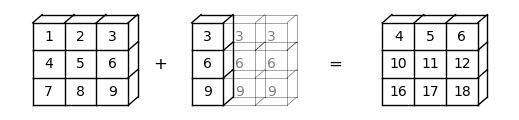

In [59]:
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '2', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3], '5', **solid)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 7, 10], '6', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3], '8', **solid)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10], '9', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 7, 9, 10], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **dotted)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **dotted)

draw_cube(ax, (6, 6.5), 1, depth, [2, 3, 4, 7, 10], '6', **solid)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 10], '9', **solid)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '4', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '5', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '6', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '10', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '11', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '12', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '16', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '17', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '18', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');


ചില cases-ൽ, ഇരു operands-ഉം expand ചെയ്യപ്പെടും.

`a -> (3,)`, `b -> (3, 1)` എന്നിവയുള്ളപ്പോൾ, `a` എന്നത് `a -> (3, 3)` ആയി expand ചെയ്യപ്പെടും, `b` എന്നത് `b -> (3, 3)` ആയി expand ചെയ്യപ്പെടും.

ഈ case-ൽ, element-wise addition-ന്റെ ഫലം ഒരു $3 \times 3$ matrix ആയിരിക്കും:

In [60]:
a = np.array([3, 6, 9])
b = np.array([2, 3, 4])
b.shape = (3, 1)

a + b

array([[ 5,  8, 11],
       [ 6,  9, 12],
       [ 7, 10, 13]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation താഴെ കാണാം:

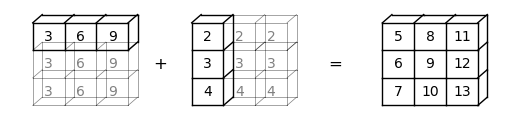

In [61]:
# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (1, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 7, 9, 10], '2', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **dotted)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **dotted)

draw_cube(ax, (6, 6.5), 1, depth, [2, 3, 4, 7, 10], '3', **solid)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '3', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '3', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 10], '4', **solid)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '4', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '4', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '5', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '8', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '11', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '6', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '9', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '12', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '10', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '13', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');

Broadcasting വളരെ useful ആണെങ്കിലും, ചിലപ്പോൾ ഇത് confusing ആയി തോന്നാം.

For example, `a -> (3, 2)`, `b -> (3,)` എന്നിവ add ചെയ്യാൻ ശ്രമിക്കാം.

In [62]:
a = np.array(
      [[1, 2],
       [4, 5],
       [7, 8]])
b = np.array([3, 6, 9])

a + b

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

`ValueError`, operands-നെ ഒരുമിച്ച് broadcast ചെയ്യാൻ കഴിഞ്ഞില്ല എന്ന് നമ്മോട് പറയുന്നു.


ഈ broadcasting എന്തുകൊണ്ട് execute ചെയ്യാൻ കഴിയില്ല എന്ന് കാണിക്കുന്ന ഒരു visual representation താഴെ കാണാം:

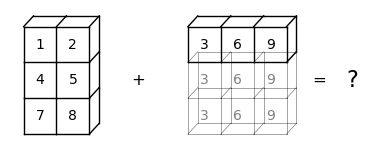

In [63]:
# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(3, 1.3), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3, 7, 10], '5', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3, 7, 10], '8', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (6, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)


ax.text(4.5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10, 7.0, '=', size=12, ha='center', va='center')
ax.text(11, 7.0, '?', size=16, ha='center', va='center');

NumPy-ക്ക് arrays-നെ ഒരേ size-ലേക്ക് expand ചെയ്യാൻ കഴിയില്ല എന്ന് നമുക്ക് കാണാം.

എന്തുകൊണ്ടെന്നാൽ, `b` എന്നത് `b -> (3,)`-ൽ നിന്നും `b -> (3, 3)`-ലേക്ക് expand ചെയ്യപ്പെടുമ്പോൾ, `b`-നെ `a -> (3, 2)`-മായി match ചെയ്യാൻ NumPy-ക്ക് കഴിയില്ല.

Higher dimensions-ലേക്ക് നീങ്ങുമ്പോൾ കാര്യങ്ങൾ കൂടുതൽ ബുദ്ധിമുട്ടാകുന്നു.

നമ്മെ സഹായിക്കാൻ, താഴെ പറയുന്ന rules-ന്റെ list ഉപയോഗിക്കാം:

* *Step 1:* രണ്ട് arrays-ന്റെ dimensions match ചെയ്യാത്തപ്പോൾ, കുറച്ച് dimensions ഉള്ളതിനെ, existing dimensions-ന്റെ ഇടതുവശത്ത് dimension(s) കൂട്ടിച്ചേർത്ത് NumPy expand ചെയ്യും.
    - For example, `a -> (3, 3)`, `b -> (3,)` ആണെങ്കിൽ, broadcasting ഇടതുവശത്ത് ഒരു dimension കൂട്ടിച്ചേർക്കും, അതിനാൽ `b -> (1, 3)` ആകും;
    - `a -> (2, 2, 2)`, `b -> (2, 2)` ആണെങ്കിൽ, broadcasting ഇടതുവശത്ത് ഒരു dimension കൂട്ടിച്ചേർക്കും, അതിനാൽ `b -> (1, 2, 2)` ആകും;
    - `a -> (3, 2, 2)`, `b -> (2,)` ആണെങ്കിൽ, broadcasting ഇടതുവശത്ത് രണ്ട് dimensions കൂട്ടിച്ചേർക്കും, അതിനാൽ `b -> (1, 1, 2)` ആകും (ഈ process, *Step 1* രണ്ട് പ്രാവശ്യം കടന്നുപോകുന്നത് ആയും കാണാം).


* *Step 2:* രണ്ട് arrays-ന് ഒരേ dimension ഉണ്ടെങ്കിലും, shapes വ്യത്യസ്തമാണെങ്കിൽ, shape index 1 ആയ dimensions expand ചെയ്യാൻ NumPy ശ്രമിക്കും.
    - For example, `a -> (1, 3)`, `b -> (3, 1)` ആണെങ്കിൽ, broadcasting `a`-യിലും `b`-യിലും shape 1 ഉള്ള dimensions expand ചെയ്യും, അതിനാൽ `a -> (3, 3)`, `b -> (3, 3)` ആകും;
    - `a -> (2, 2, 2)`, `b -> (1, 2, 2)` ആണെങ്കിൽ, broadcasting `b`-യുടെ ആദ്യത്തെ dimension expand ചെയ്യും, അതിനാൽ `b -> (2, 2, 2)` ആകും;
    - `a -> (3, 2, 2)`, `b -> (1, 1, 2)` ആണെങ്കിൽ, broadcasting `b`-യെ shape 1 ഉള്ള എല്ലാ dimensions-ലും expand ചെയ്യും, അതിനാൽ `b -> (3, 2, 2)` ആകും.

* *Step 3:* Step 1, 2 എന്നിവയ്ക്ക് ശേഷം, രണ്ട് arrays-ഉം ഇപ്പോഴും match ചെയ്യുന്നില്ലെങ്കിൽ, ഒരു `ValueError` raise ചെയ്യപ്പെടും. For example, `a -> (2, 2, 3)`, `b -> (2, 2)` ആണെന്ന് കരുതുക:
    - *Step 1* പ്രകാരം, `b` എന്നത് `b -> (1, 2, 2)` ആയി expand ചെയ്യപ്പെടും;
    - *Step 2* പ്രകാരം, `b` എന്നത് `b -> (2, 2, 2)` ആയി expand ചെയ്യപ്പെടും;
    - ആദ്യത്തെ രണ്ട് steps-ന് ശേഷവും അവ പരസ്പരം match ചെയ്യുന്നില്ല എന്ന് നമുക്ക് കാണാം. അതിനാൽ, ഒരു `ValueError` raise ചെയ്യപ്പെടും.



## Mutability and Copying Arrays

NumPy arrays, Python lists-നെ പോലെ mutable data types ആണ്.

അതായത്, initialization-ന് ശേഷം അവയുടെ contents memory-യിൽ alter ചെയ്യാൻ (mutate ചെയ്യാൻ) കഴിയും.

ഇത് convenient ആണ്, പക്ഷേ Python-ന്റെ naming, reference model എന്നിവയുമായി combine ചെയ്യുമ്പോൾ, NumPy beginners-ന് mistakes-ലേക്ക് നയിക്കാം.

ഈ section-ൽ കുറച്ച് key issues നമുക്ക് നോക്കാം.


### Mutability

Mutability-യുടെ examples നമ്മൾ മുകളിൽ already കണ്ടു.

NumPy array-യുടെ mutation-ന്റെ മറ്റൊരു example താഴെ കാണാം:

In [64]:
a = np.array([42, 44])
a

array([42, 44])

In [65]:
a[-1] = 0  # Change last element to 0
a

array([42,  0])

Mutability താഴെ പറയുന്ന behavior-ലേക്ക് നയിക്കുന്നു (ഇത് MATLAB programmers-നെ ഞെട്ടിക്കാം...)

In [66]:
rng = np.random.default_rng()
a = rng.standard_normal(3)
a

array([-0.59207913, -0.15374652,  1.20933264])

In [67]:
b = a
b[0] = 0.0
a

array([ 0.        , -0.15374652,  1.20933264])

സംഭവിച്ചത് എന്തെന്നാൽ, `b`-നെ മാറ്റിയപ്പോൾ നമ്മൾ `a`-യെയും മാറ്റിയിരിക്കുന്നു.

`b` എന്ന name, `a`-യുമായി bind ചെയ്യപ്പെട്ടിരിക്കുന്നു, ഇത് ആ array-യുടെ മറ്റൊരു reference മാത്രമായി മാറുന്നു (Python assignment model {doc}`later in the course <python_advanced_features>` കൂടുതൽ വിശദമായി describe ചെയ്യുന്നു).

അതിനാൽ, ആ array-യിൽ changes നടത്താൻ അതിന് equal rights ഉണ്ട്.

വാസ്തവത്തിൽ ഇതാണ് ഏറ്റവും sensible ആയ default behavior!

ഇതിനർത്ഥം, copies ഉണ്ടാക്കുന്നതിന് പകരം, data-യിലേക്കുള്ള pointers മാത്രമാണ് നമ്മൾ pass ചെയ്യുന്നത് എന്നാണ്.

Copies ഉണ്ടാക്കുന്നത് speed-ന്റെയും memory-യുടെയും കാര്യത്തിൽ expensive ആണ്.

### Making Copies

ആവശ്യമുള്ളപ്പോൾ `b`-നെ `a`-യുടെ ഒരു independent copy ആക്കാൻ കഴിയും, തീർച്ചയായും.

ഇത് `np.copy` ഉപയോഗിച്ച് ചെയ്യാം:

In [68]:
a = rng.standard_normal(3)
a

array([ 0.62521596, -0.69597426, -0.3079892 ])

In [69]:
b = np.copy(a)
b

array([ 0.62521596, -0.69597426, -0.3079892 ])

ഇപ്പോൾ `b` എന്നത് ഒരു independent copy ആണ് (ഇതിനെ *deep copy* എന്ന് വിളിക്കുന്നു):

In [70]:
b[:] = 1
b

array([1., 1., 1.])

In [71]:
a

array([ 0.62521596, -0.69597426, -0.3079892 ])

`b`-യിലെ change, `a`-യെ ബാധിച്ചിട്ടില്ല എന്ന് ശ്രദ്ധിക്കുക.




## Additional Features

NumPy-യുടെ മറ്റ് ചില useful features നമുക്ക് നോക്കാം.


### Universal Functions

```{index} single: NumPy; Vectorized Functions
```

Arrays-ൽ *element-wise* ആയി act ചെയ്യുന്ന standard functions ആയ `log`, `exp`, `sin`, തുടങ്ങിയവയുടെ versions NumPy നൽകുന്നു:

In [72]:
z = np.array([1, 2, 3])
np.sin(z)

array([0.84147098, 0.90929743, 0.14112001])

താഴെ കാണിച്ചിരിക്കുന്നത് പോലുള്ള explicit element-by-element loops-ന്റെ ആവശ്യം ഇത് ഒഴിവാക്കുന്നു:

In [73]:
n = len(z)
y = np.empty(n)
for i in range(n):
    y[i] = np.sin(z[i])

Arrays-ൽ element-wise ആയി act ചെയ്യുന്നതിനാൽ, ഈ functions-നെ ചിലപ്പോൾ **vectorized functions** എന്ന് വിളിക്കുന്നു.

NumPy-speak-ൽ, ഇവയെ **ufuncs**, അല്ലെങ്കിൽ **universal functions** എന്നും വിളിക്കുന്നു.

മുകളിൽ നമ്മൾ കണ്ടത് പോലെ, സാധാരണ arithmetic operations (`+`, `*`, തുടങ്ങിയവ) element-wise ആയും work ചെയ്യുന്നു, ഇവയെ ufuncs-ഉമായി combine ചെയ്യുമ്പോൾ, വളരെ വലിയൊരു set of fast element-wise functions ലഭിക്കുന്നു.

In [74]:
z

array([1, 2, 3])

In [75]:
(1 / np.sqrt(2 * np.pi)) * np.exp(- 0.5 * z**2)

array([0.24197072, 0.05399097, 0.00443185])

എല്ലാ user-defined functions-ഉം element-wise ആയി act ചെയ്യണമെന്നില്ല.

For example, താഴെ define ചെയ്തിരിക്കുന്ന `f` എന്ന function-ന് ഒരു NumPy array pass ചെയ്യുന്നത് ഒരു `ValueError`-ന് കാരണമാകുന്നു:

In [76]:
def f(x):
    return 1 if x > 0 else 0

NumPy function `np.where`, ഒരു vectorized alternative നൽകുന്നു:

In [77]:
x = rng.standard_normal(4)
x

array([ 0.19022626,  1.34952412,  0.13611107, -0.28245676])

In [78]:
np.where(x > 0, 1, 0)  # Insert 1 if x > 0 true, otherwise 0

array([1, 1, 1, 0])

തന്നിരിക്കുന്ന ഒരു function vectorize ചെയ്യാൻ `np.vectorize`-ഉം ഉപയോഗിക്കാം:

In [79]:
f = np.vectorize(f)
f(x)                # Passing the same vector x as in the previous example

array([1, 1, 1, 0])

എന്നിരുന്നാലും, ഈ approach, കൂടുതൽ carefully crafted ആയ ഒരു vectorized function-ന്റെ speed എപ്പോഴും obtain ചെയ്യില്ല.

(പിന്നീട് നമ്മൾ കാണും, JAX-ന് `np.vectorize`-ന്റെ ഒരു powerful version ഉണ്ട്, ഇത് പലപ്പോഴും highly efficient code generate ചെയ്യും.)


### Comparisons

```{index} single: NumPy; Comparisons
```

സാധാരണയായി, arrays-ലെ comparisons element-wise ആയാണ് ചെയ്യുന്നത്:

In [80]:
z = np.array([2, 3])
y = np.array([2, 3])
z == y

array([ True,  True])

In [81]:
y[0] = 5
z == y

array([False,  True])

In [82]:
z != y

array([ True, False])

`>`, `<`, `>=`, `<=` എന്നിവയ്ക്കും situation similar ആണ്.

Scalars-നെതിരെയും നമുക്ക് comparisons ചെയ്യാം:

In [83]:
z = np.linspace(0, 10, 5)
z

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [84]:
z > 3

array([False, False,  True,  True,  True])

*Conditional extraction*-ന് ഇത് പ്രത്യേകിച്ചും useful ആണ്:

In [85]:
b = z > 3
b

array([False, False,  True,  True,  True])

In [86]:
z[b]

array([ 5. ,  7.5, 10. ])

തീർച്ചയായും നമുക്ക് ഇത് ഒറ്റ step-ൽ ചെയ്യാം---അതാണ് പലപ്പോഴും ചെയ്യുന്നത്:

In [87]:
z[z > 3]

array([ 5. ,  7.5, 10. ])

### Sub-packages

Scientific programming-മായി ബന്ധപ്പെട്ട ചില additional functionality, NumPy അതിന്റെ sub-packages വഴി നൽകുന്നു.

NumPy-യുടെ [random `Generator`](https://numpy.org/doc/stable/reference/random/generator.html#random-generator) ഉപയോഗിച്ച് random variables generate ചെയ്യുന്നത് നമ്മൾ already കണ്ടു.

In [88]:
z = rng.standard_normal(10000)  # Generate standard normals
y = rng.binomial(10, 0.5, size=1000)    # 1,000 draws from Bin(10, 0.5)
y.mean()

np.float64(4.96)

സാധാരണയായി ഉപയോഗിക്കുന്ന മറ്റൊരു subpackage ആണ് np.linalg:

In [89]:
A = np.array([[1, 2], [3, 4]])

np.linalg.det(A)           # Compute the determinant

np.float64(-2.0000000000000004)

In [90]:
np.linalg.inv(A)           # Compute the inverse

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

```{index} single: SciPy
```

```{index} single: Python; SciPy
```

ഈ functionality-യുടെ ഭൂരിഭാഗവും [SciPy](https://scipy.org/)-യിലും ലഭ്യമാണ്, NumPy-യുടെ മുകളിൽ build ചെയ്തിരിക്കുന്ന modules-ന്റെ ഒരു collection ആണിത്.

SciPy versions നമ്മൾ {doc}`soon <scipy>` കൂടുതൽ വിശദമായി cover ചെയ്യും.

NumPy-യിൽ ലഭ്യമായതിന്റെ ഒരു comprehensive list-ന് [this documentation](https://numpy.org/doc/stable/reference/routines.html) കാണുക.


### Implicit Multithreading 

[Previously](need_for_speed) multithreading വഴിയുള്ള parallelization-ന്റെ concept നമ്മൾ discuss ചെയ്തു.

NumPy അതിന്റെ compiled code-ന്റെ ഭൂരിഭാഗത്തിലും multithreading implement ചെയ്യാൻ ശ്രമിക്കുന്നു.

ഇത് action-ൽ കാണാൻ ഒരു example നമുക്ക് നോക്കാം.

അടുത്ത code piece, randomly generate ചെയ്ത ധാരാളം matrices-ന്റെ eigenvalues compute ചെയ്യുന്നു.

ഇത് run ചെയ്യാൻ കുറച്ച് seconds എടുക്കും.

In [91]:
n = 20
m = 1000
for i in range(n):
    X = rng.standard_normal((m, m))
    λ = np.linalg.eigvals(X)

ഇനി, ഈ code run ചെയ്യുമ്പോൾ നമ്മുടെ machine-ലെ htop system monitor-ന്റെ output നമുക്ക് നോക്കാം:

```{figure} /_static/lecture_specific/parallelization/htop_parallel_npmat.png
:scale: 80
```

8 CPUs-ൽ 4 എണ്ണം full speed-ൽ run ചെയ്യുന്നത് നമുക്ക് കാണാം.

NumPy-യുടെ `eigvals` routine tasks-നെ neat ആയി split up ചെയ്ത് വ്യത്യസ്ത threads-ലേക്ക് distribute ചെയ്യുന്നത് കൊണ്ടാണ് ഇത്.





## Exercises


```{exercise-start}
:label: np_ex1
```

Consider the polynomial expression

```{math}
:label: np_polynom

p(x) = a_0 + a_1 x + a_2 x^2 + \cdots a_N x^N = \sum_{n=0}^N a_n x^n
```

{ref}`Earlier <pyess_ex2>`, you wrote a simple function `p(x, coeff)` to evaluate {eq}`np_polynom` without considering efficiency.

Now write a new function that does the same job, but uses NumPy arrays and array operations for its computations, rather than any form of Python loop.

(Such functionality is already implemented as `np.poly1d`, but for the sake of the exercise don't use this class)

```{hint}
:class: dropdown
Use `np.cumprod()`
```
```{exercise-end}
```

```{solution-start} np_ex1
:class: dropdown
```

This code does the job

In [92]:
def p(x, coef):
    X = np.ones_like(coef)
    X[1:] = x
    y = np.cumprod(X)   # y = [1, x, x**2,...]
    return coef @ y

Let's test it

In [93]:
x = 2
coef = np.linspace(2, 4, 3)
print(coef)
print(p(x, coef))
# For comparison
q = np.poly1d(np.flip(coef))
print(q(x))

[2. 3. 4.]
24.0
24.0


```{solution-end}
```


```{exercise-start}
:label: np_ex2
```

Let `q` be a NumPy array of length `n` with `q.sum() == 1`.

Suppose that `q` represents a [probability mass function](https://en.wikipedia.org/wiki/Probability_mass_function).

We wish to generate a discrete random variable $x$ such that $\mathbb P\{x = i\} = q_i$.

In other words, `x` takes values in `range(len(q))` and `x = i` with probability `q[i]`.

The standard (inverse transform) algorithm is as follows:

* Divide the unit interval $[0, 1]$ into $n$ subintervals $I_0, I_1, \ldots, I_{n-1}$ such that the length of $I_i$ is $q_i$.
* Draw a uniform random variable $U$ on $[0, 1]$ and return the $i$ such that $U \in I_i$.

The probability of drawing $i$ is the length of $I_i$, which is equal to $q_i$.

We can implement the algorithm as follows

In [94]:
from random import uniform

def sample(q):
    a = 0.0
    U = uniform(0, 1)
    for i in range(len(q)):
        if a < U <= a + q[i]:
            return i
        a = a + q[i]

If you can't see how this works, try thinking through the flow for a simple example, such as `q = [0.25, 0.75]`
It helps to sketch the intervals on paper.

Your exercise is to speed it up using NumPy, avoiding explicit loops

```{hint}
:class: dropdown

Use `np.searchsorted` and `np.cumsum`

```

If you can, implement the functionality as a class called `DiscreteRV`, where

* the data for an instance of the class is the vector of probabilities `q`
* the class has a `draw()` method, which returns one draw according to the algorithm described above

If you can, write the method so that `draw(k)` returns `k` draws from `q`.

```{exercise-end}
```

```{solution-start} np_ex2
:class: dropdown
```

Here's our first pass at a solution:

In [95]:
from numpy import cumsum

class DiscreteRV:
    """
    Generates an array of draws from a discrete random variable with vector of
    probabilities given by q.
    """

    def __init__(self, q, seed=None):
        """
        The argument q is a NumPy array, or array like, nonnegative and sums
        to 1.

        The argument seed sets the seed for the underlying random number
        generator; with the default seed=None, draws are not reproducible
        across runs.
        """
        self.q = q
        self.Q = cumsum(q)
        self.rng = np.random.default_rng(seed)

    def draw(self, k=1):
        """
        Returns k draws from q. For each such draw, the value i is returned
        with probability q[i].
        """
        return self.Q.searchsorted(self.rng.uniform(0, 1, size=k))

The logic is not obvious, but if you take your time and read it slowly,
you will understand.

There is a problem here, however.

Suppose that `q` is altered after an instance of `DiscreteRV` is
created, for example by

In [96]:
q = (0.1, 0.9)
d = DiscreteRV(q)
d.q = (0.5, 0.5)

The problem is that `Q` does not change accordingly, and `Q` is the
data used in the `draw` method.

To deal with this, one option is to compute `Q` every time the draw
method is called.

But this is inefficient relative to computing `Q` once-off.

A better option is to use descriptors.

A solution from the [quantecon
library](https://github.com/QuantEcon/QuantEcon.py/tree/main/quantecon)
using descriptors that behaves as we desire can be found
[here](https://github.com/QuantEcon/QuantEcon.py/blob/main/quantecon/discrete_rv.py).

```{solution-end}
```


```{exercise}
:label: np_ex3

Recall our {ref}`earlier discussion <oop_ex1>` of the empirical cumulative distribution function.

Your task is to

1. Make the `__call__` method more efficient using NumPy.
1. Add a method that plots the ECDF over $[a, b]$, where $a$ and $b$ are method parameters.
```

```{solution-start} np_ex3
:class: dropdown
```

An example solution is given below.

In essence, we've just taken [this code](https://github.com/QuantEcon/QuantEcon.py/blob/main/quantecon/ecdf.py)
from QuantEcon and added in a plot method

In [97]:
"""
Modifies ecdf.py from QuantEcon to add in a plot method

"""

class ECDF:
    """
    One-dimensional empirical distribution function given a vector of
    observations.

    Parameters
    ----------
    observations : array_like
        An array of observations

    Attributes
    ----------
    observations : array_like
        An array of observations

    """

    def __init__(self, observations):
        self.observations = np.asarray(observations)

    def __call__(self, x):
        """
        Evaluates the ecdf at x

        Parameters
        ----------
        x : scalar(float)
            The x at which the ecdf is evaluated

        Returns
        -------
        scalar(float)
            Fraction of the sample less than x

        """
        return np.mean(self.observations <= x)

    def plot(self, ax, a=None, b=None):
        """
        Plot the ecdf on the interval [a, b].

        Parameters
        ----------
        a : scalar(float), optional(default=None)
            Lower endpoint of the plot interval
        b : scalar(float), optional(default=None)
            Upper endpoint of the plot interval

        """

        # === choose reasonable interval if [a, b] not specified === #
        if a is None:
            a = self.observations.min() - self.observations.std()
        if b is None:
            b = self.observations.max() + self.observations.std()

        # === generate plot === #
        x_vals = np.linspace(a, b, num=100)
        f = np.vectorize(self.__call__)
        ax.plot(x_vals, f(x_vals))
        plt.show()

Here's an example of usage

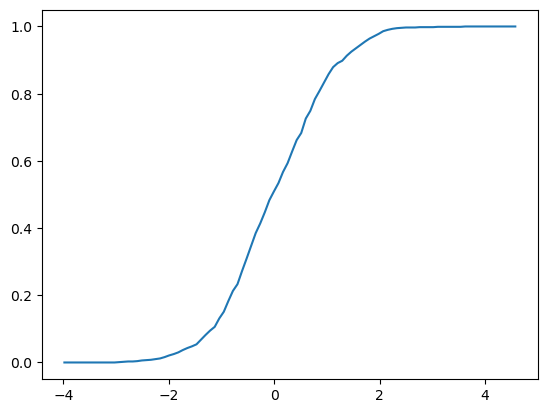

In [98]:
fig, ax = plt.subplots()
rng = np.random.default_rng()
X = rng.standard_normal(1000)
F = ECDF(X)
F.plot(ax)

```{solution-end}
```


```{exercise-start}
:label: np_ex4
```

Recall that [broadcasting](broadcasting) in NumPy can help us conduct element-wise operations on arrays with different number of dimensions without using `for` loops.

In this exercise, try to use `for` loops to replicate the result of the following broadcasting operations.

**Part 1**: Try to replicate this simple example using `for` loops and compare your results with the broadcasting operation below.

In [99]:
rng = np.random.default_rng(123)
x = rng.standard_normal((4, 4))
y = rng.standard_normal(4)
A = x / y

Here is the output

In [100]:
print(A)

[[-0.64562663  0.55727833 -4.13068155  0.57428108]
 [ 0.60065994 -0.87444021  2.04128976  1.60450491]
 [-0.20665053  0.488491   -0.31163862 -4.51767283]
 [ 0.77815951  1.01684966 -3.20810109  0.40359261]]


**Part 2**: Move on to replicate the result of the following broadcasting operation. Meanwhile, compare the speeds of broadcasting and the `for` loop you implement.

For this part of the exercise you can use the `qe.Timer()` context manager from the `quantecon` library to time the execution. 

Let's make sure this library is installed.

In [101]:
!pip install quantecon

Now we can import the quantecon package.

In [102]:
rng = np.random.default_rng(123)
x = rng.standard_normal((1000, 100, 100))
y = rng.standard_normal(100)

with qe.Timer("Broadcasting operation"):
    B = x / y

Broadcasting operation: 0.0114 seconds elapsed


Here is the output

In [103]:
print(B)

[[[ 1.11459186e+00  6.49554639e-01 -1.39222984e+00 ...  1.29919811e+00
    4.05186703e+00 -7.40287138e+01]
  [ 5.81192956e-01 -2.92842384e+00  3.21336857e-01 ...  1.20991613e+00
    2.27427587e+00  1.44385102e+02]
  [ 1.05593413e+00  1.42938670e+00  4.45508796e-01 ...  4.01152744e-01
    2.84732007e+00  8.92867644e+01]
  ...
  [-2.74886903e-02  1.26977472e+00  3.14108995e-01 ...  1.11710121e-01
    1.42995646e+00 -3.11820183e+01]
  [ 2.37232237e-02 -1.07344880e+00 -6.84853323e-02 ...  1.34568899e-01
   -1.03734701e-01 -1.06565258e+02]
  [-1.74039841e+00 -3.01228229e+00 -9.49433502e-01 ...  1.44494147e-01
   -7.23108571e+00 -2.90325461e+01]]

 [[ 5.31486218e-01  2.93920784e+00 -2.44783577e-01 ... -6.32917660e-01
   -2.52543447e+00 -5.31568329e+01]
  [-4.73496558e-01  1.49038936e-01  1.68780916e+00 ...  2.05750194e-01
   -1.40524927e+00 -6.14593964e-01]
  [-2.74888585e+00 -2.33570490e+00  3.41515715e-01 ...  1.24702883e-01
   -1.68468042e+00  8.33959001e+01]
  ...
  [-8.36506904e-01 -1.8

```{exercise-end}
```


```{solution-start} np_ex4
:class: dropdown
```

**Part 1 Solution**

In [104]:
rng = np.random.default_rng(123)
x = rng.standard_normal((4, 4))
y = rng.standard_normal(4)

C = np.empty_like(x)
n = len(x)
for i in range(n):
    for j in range(n):
        C[i, j] = x[i, j] / y[j]

Compare the results to check your answer

In [105]:
print(C)

[[-0.64562663  0.55727833 -4.13068155  0.57428108]
 [ 0.60065994 -0.87444021  2.04128976  1.60450491]
 [-0.20665053  0.488491   -0.31163862 -4.51767283]
 [ 0.77815951  1.01684966 -3.20810109  0.40359261]]


You can also use `array_equal()` to check your answer

In [106]:
print(np.array_equal(A, C))

True


**Part 2 Solution**

In [107]:
rng = np.random.default_rng(123)
x = rng.standard_normal((1000, 100, 100))
y = rng.standard_normal(100)

with qe.Timer("For loop operation"):
    D = np.empty_like(x)
    d1, d2, d3 = x.shape
    for i in range(d1):
        for j in range(d2):
            for k in range(d3):
                D[i, j, k] = x[i, j, k] / y[k]

For loop operation: 3.7055 seconds elapsed


Note that the `for` loop takes much longer than the broadcasting operation.

Compare the results to check your answer

In [108]:
print(D)

[[[ 1.11459186e+00  6.49554639e-01 -1.39222984e+00 ...  1.29919811e+00
    4.05186703e+00 -7.40287138e+01]
  [ 5.81192956e-01 -2.92842384e+00  3.21336857e-01 ...  1.20991613e+00
    2.27427587e+00  1.44385102e+02]
  [ 1.05593413e+00  1.42938670e+00  4.45508796e-01 ...  4.01152744e-01
    2.84732007e+00  8.92867644e+01]
  ...
  [-2.74886903e-02  1.26977472e+00  3.14108995e-01 ...  1.11710121e-01
    1.42995646e+00 -3.11820183e+01]
  [ 2.37232237e-02 -1.07344880e+00 -6.84853323e-02 ...  1.34568899e-01
   -1.03734701e-01 -1.06565258e+02]
  [-1.74039841e+00 -3.01228229e+00 -9.49433502e-01 ...  1.44494147e-01
   -7.23108571e+00 -2.90325461e+01]]

 [[ 5.31486218e-01  2.93920784e+00 -2.44783577e-01 ... -6.32917660e-01
   -2.52543447e+00 -5.31568329e+01]
  [-4.73496558e-01  1.49038936e-01  1.68780916e+00 ...  2.05750194e-01
   -1.40524927e+00 -6.14593964e-01]
  [-2.74888585e+00 -2.33570490e+00  3.41515715e-01 ...  1.24702883e-01
   -1.68468042e+00  8.33959001e+01]
  ...
  [-8.36506904e-01 -1.8

In [109]:
print(np.array_equal(B, D))

True


```{solution-end}
```